The results we've obtained so far for the Green's function approach that we're using to calculate the transmission spectrum of our system with two atoms doesn't look correct.  So far, we're thinking that this may be because we aren't really calculating the transmission correctly.  We've been assuming that it should be proportional to the probability of ending up in a state with a photon in the cavity mode because that's what the Ningyuang paper does for their perturbation theory and it seems like that's what is done in the Kurucz paper as well.  With this in mind, I figured that it would probably be a good idea to have a notebook for testing our method in a couple of physically important setups where we have a better idea of what the results should be.  I'll consider systems with one and two atoms in these tests.

### Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym
from scipy import linalg
import time
from scipy.optimize import linear_sum_assignment

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [282]:
def get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, N):
    """
    Function for calculating the Hamiltonian for our two atom system
    :param ωc:   the cavity mode frequency
    :param ω21:  the frequency of the |1>-|2> transition
    :param Δ1s:  array of the detunings between the freq. of the |0>-|1> transition of the jth atom and the probe laser
    :param κ:    the cavity loss rate
    :param γ10s: array of the decay rates of the |1>-|0> transition of the jth atom
    :param γ21s: array of the decay rates of the |2>-|1> transition of the jth atom
    :param g10s: array of coupling strengths between the probe laser and the |0>-|1> transition of the jth atom
    :param g21s: array of coupling strengths between the cavity mode and the |1>-|2> transition of the jth atom
    :param λ:    coupling strength of drive laser
    :param a:    cavity annihilation operator
    :param σ10:  atomic lowering operator for |0><1|
    :param σ21:  atomic lowering operator for |1><2|
    :param Ic:   identity over the cavity basis
    :param Ia:   identity over the atomic basis
    :param N:    the number of atoms
    :return:     the Hamiltonian
    """
    # Create a list of identity matrices
    base_list = [Ic]
    base_list += [Ia for i in range(N)]

    # Define the cavity portion of H0 by modifying the base list
    temp_list = base_list.copy()
    temp_list[0] = a.dag() * a
    H_cav = (ωc - 1j*κ) * qu.tensor(temp_list)

    # Define atomic portion of H0 by modifying the base list
    # First create Qobj of zeros
    H_atom = 0 * qu.qeye(H_cav.dims[0])

    # Now loop over number of atoms
    for i in range(N):
        # Copy base list 
        temp_list = base_list.copy()

        # Add term for σ10.dag() * σ10 of ith atom to H_atom
        temp_list[i+1] = σ10.dag() * σ10
        H_atom += -(Δ1s[i] + 1j*γ10s[i]) * qu.tensor(temp_list)

        # Add term for σ21.dag() * σ21
        temp_list[i+1] = σ21.dag() * σ21
        H_atom += (ω21 - Δ1s[i] - 1j*γ21s[i]) * qu.tensor(temp_list)

        # Add term for semiclassical coupling
        temp_list[i+1] = σ10.dag() + σ10
        H_atom += g10s[i] * qu.tensor(temp_list)

    # Return the total
    return H_cav + H_atom

In [4]:
def get_Vd(λ, a, Ia, N):
    base_list = [a.dag() + a]
    base_list += [Ia for i in range(N)]
    return λ * qu.tensor(base_list)

In [5]:
def get_V(g21s, a, σ21, Ia, N):
    # Define base lists
    base_list = [a]
    base_list += [Ia for i in range(N)]
    base_list_dag = [a.dag()]
    base_list_dag += [Ia for i in range(N)]

    # Create empty V
    V = 0 * qu.qeye(qu.tensor(base_list).dims[0])
    
    # Now loop over number of atoms
    for i in range(N):
        # Copy base lists
        temp_list = base_list.copy()
        temp_list_dag = base_list_dag.copy()

        # Modify the spot of the ith atom
        temp_list[i+1] = σ21.dag()
        temp_list_dag[i+1] = σ21

        # Add to V
        V += g21s[i] * (qu.tensor(temp_list) + qu.tensor(temp_list_dag))
    
    return V

In [6]:
def get_H_atom(ω21, Δ1, γ10, γ21, g10, σ10, σ21):
    # Calculate the Hamiltonian
    H_atom = -(Δ1 + 1j*γ10) * σ10.dag() * σ10
    H_atom += (ω21 - Δ1 - 1j*γ21) * σ21.dag() * σ21
    H_atom += g10 * (σ10.dag() + σ10)
    return H_atom    

In [7]:
def exact_resolvent(z, H):
    return (z - H).inv()

In [8]:
def get_sorted_eigs(H0s):
    # Create arrays for storing sorted values and vectors
    sor_eig_vals = np.zeros((len(H0s), H0s[0].full().shape[0]), dtype=complex)
    sor_eig_vecs = np.zeros((len(H0s), H0s[0].full().shape[0], H0s[0].full().shape[0]), dtype=complex)

    # Store the first values
    eig_vals0, eig_vecs0 = np.linalg.eig(H0s[0].full())
    sor_eig_vals[0] = eig_vals0
    sor_eig_vecs[0] = eig_vecs0

    # Loop over list of H0s
    for i in range(1, len(H0s)):
        # Get the ith eigenvalues and eigenvects
        raw_eig_vals, raw_eig_vecs = np.linalg.eig(H0s[i].full())

        # Calculate the overlap matrix
        ovlp_mat = np.abs(sor_eig_vecs[i-1].conj().T @ raw_eig_vecs) ** 2

        # Calculate previous and new indices using linear_sum_assignment
        prev_ind, new_ind = linear_sum_assignment(-ovlp_mat)

        # Store according to the new ranking
        sor_eig_vals[i] = raw_eig_vals[new_ind]
        sor_eig_vecs[i] = raw_eig_vecs[:, new_ind]

    return sor_eig_vals, sor_eig_vecs

In [9]:
def get_Rx_two_term(z, ϕb, V, H0_eigs):
    """
    Function for calculating the level shift function
    :param z:       the complex argument of the level shift function
    :param ϕb:      the eigenstate of H0 that we want to calculate the level shift function for
    :param V:       the interaction part of the Hamiltonian
    :param H0_eigs: the eigenstates and eigenvalues of the core part of the Hamiltonian
    :returns:       the value of the level shift function
    """
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([ϕb])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += ϕb.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * ϕb

    return Rx

In [10]:
def get_Rx_four_term(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    return Rx

In [11]:
def get_Rx_six_term(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    for Ek, k in zip(masked_vals, masked_states):
                        for El, l in zip(masked_vals, masked_states):
                            temp = x.dag() * V * y * 1 / (z[i] - Ey)
                            temp *= y.dag() * V * p * 1 / (z[i] - Ep)
                            temp *= p.dag() * V * q * 1 / (z[i] - Eq)
                            temp *= q.dag() * V * k * 1 / (z[i] - Ek)
                            temp *= k.dag() * V * l * 1 / (z[i] - El)
                            temp *= l.dag() * V * x
                            Rx[i] += temp

    return Rx

### Parameters

In [12]:
# Define decay terms
#ωc = 0                                    # Frequency of the cavity mode
#ω21 = 0                                   # Frequency of the |1>-|2> transition
#Δ1s = [0, 0]                              # Detuning of each atom bottom transition (for now all zero)
κ = 1                                     # The loss rate of the cavity mode
γ10s = np.ones(2)                         # The decay rates of the atoms from |1> to |0> (all same for now)
γ21s = 0.5 * np.ones(2)                  # The decay rates of the atoms from |2> to |1> (all same for now)
#g10s = 0 * np.ones(N)                     # Coupling of |0>-|1> transition for each atom (all same for now)
#g21s = 0 * np.ones(N)                     # Coupling of |1>-|2> transition for each atom (all same for now)

In [13]:
# Define operators for defining H
a = qu.destroy(2)
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

# Define identity matrices over these spaces for convenience
Ic = qu.qeye(2)
Ia = qu.qeye(3)

In [14]:
# Define detuning parameter
z = np.linspace(-50, 50, 1000)

### a) Single Atom

#### a) No detunings, no couplings
First, we want to check our results when we have everything on resonance ($\omega_{21}^j=\omega_c$, $\Delta_1^j=0$) and have turned off the couplings ($g_{10}^j = g_{21}^j = 0$).  We're interested in calculating $|\langle1,\phi_i|G(z)|1,\phi_i\rangle|^2$ where $|\phi_i\rangle$ are the eigenstates of the atoms where the atoms are in linear combinations of $|0\rangle$ and $|1\rangle$.

In [283]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [0]
g10s = [0]
g21s = [0]

In [284]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)

In [285]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [286]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i]+ωc, sa_H0+sa_V) for i in range(z.shape[0])]

In [287]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([0.-1.j , 0.-0.5j, 0.+0.j ]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [1.]
        [0.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[1.]
        [0.]
        [0.]]                                                                ],
      dtype=object))


In [288]:
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.-0.5j 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-2.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.5j]]

In [289]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([0.-2.j , 0.-1.5j, 0.-1.j , 0.-1.j , 0.-0.5j, 0.+0.j ]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [1.]
         [0.]

In [196]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][4].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][3].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

In [197]:
# Calculate the two term level shift functions
Rx_2term_e0 = get_Rx_two_term(z, e0, sa_V, sa_H0_eigs)
Rx_2term_e2 = get_Rx_two_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the four term level shift functions
Rx_4term_e0 = get_Rx_four_term(z, e0, sa_V, sa_H0_eigs)
Rx_4term_e2 = get_Rx_four_term(z, e2, sa_V, sa_H0_eigs)

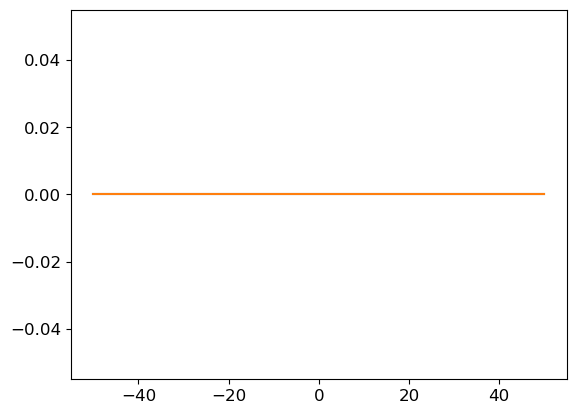

In [198]:
plt.plot(z, Rx_4term_e0.real)
plt.plot(z, Rx_4term_e0.imag)

In [199]:
# Calculate the approximate Gs using the level shift functions
approx_G_2term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][4] - Rx_2term_e0[i]) for i in range(z.shape[0])])
approx_G_2term_e0 = np.abs(approx_G_2term_e0_tamp) ** 2
approx_G_2term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][3] - Rx_2term_e2[i]) for i in range(z.shape[0])])
approx_G_2term_e2 = np.abs(approx_G_2term_e2_tamp) ** 2

approx_G_4term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][4] - Rx_4term_e0[i]) for i in range(z.shape[0])])
approx_G_4term_e0 = np.abs(approx_G_4term_e0_tamp) ** 2
approx_G_4term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][3] - Rx_4term_e2[i]) for i in range(z.shape[0])])
approx_G_4term_e2 = np.abs(approx_G_4term_e2_tamp) ** 2

Text(0.5, 1.0, '$|\\phi_i\\rangle = |\\epsilon_2\\rangle$')

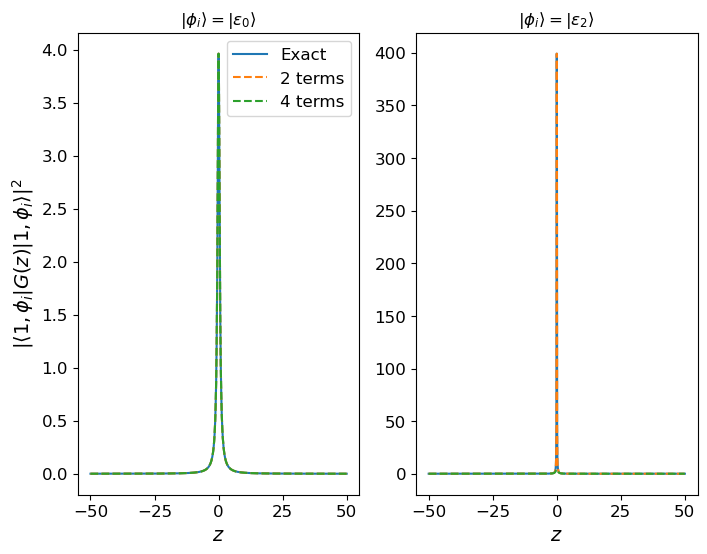

In [200]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
#ax[0].plot(z, e0_tf / e0_tf.max(), label='Exact')
#ax[0].plot(z, approx_G_2term_e0 / approx_G_2term_e0.max(), '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0 / approx_G_2term_e0.max(), '--', label='4 terms')
ax[0].plot(z, e0_tf, label='Exact')
ax[0].plot(z, approx_G_2term_e0, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
ax[0].set_title("$|\\phi_i\\rangle = |\\epsilon_0\\rangle$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tf)
ax[1].plot(z, approx_G_2term_e2, '--')
ax[1].plot(z, approx_G_4term_e0, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$|\\phi_i\\rangle = |\\epsilon_2\\rangle$")

Text(0.5, 1.0, 'Imag')

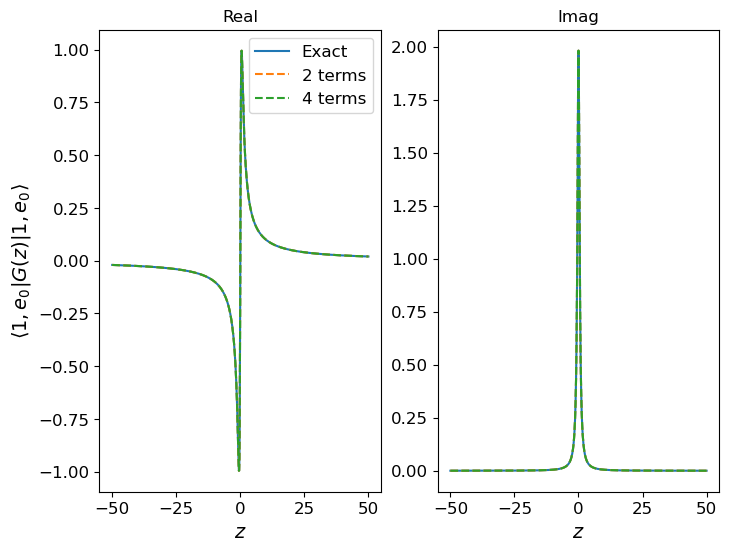

In [203]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_0|G(z)|1,e_0\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e0_tamp.imag)
ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

Text(0.5, 1.0, 'Imag')

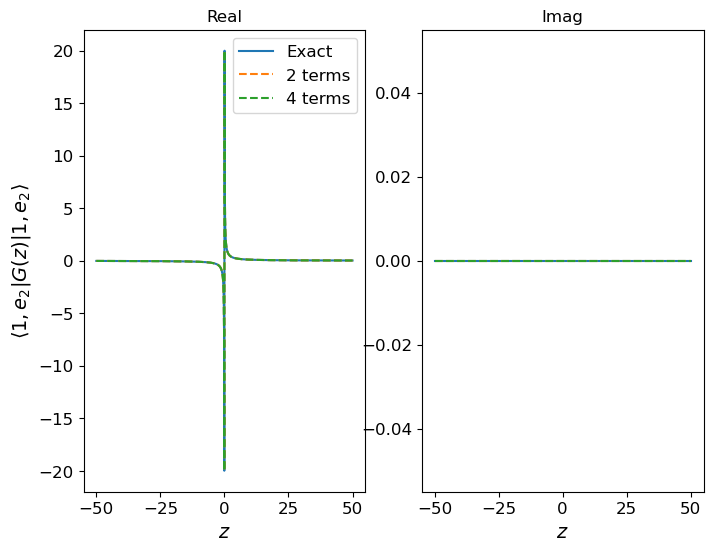

In [204]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e2_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e2_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e2_tamp.real, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_2|G(z)|1,e_2\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.imag)
ax[1].plot(z, approx_G_2term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e2_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

#### b) $\Delta_1 \neq 0$
Now we want to check that changing the detuning doesn't change the transmission spectrum when the atoms are completely disconnected from the atoms.

In [321]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [5]
g10s = [0]
g21s = [0]

In [322]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j  -5.-1.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j  -5.-0.5j  0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.-1.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+0.j  -5.-2.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j  -5.-1.5j]]

In [323]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [324]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [325]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([-5.-1.j , -5.-0.5j,  0.+0.j ]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [1.]
        [0.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[1.]
        [0.]
        [0.]]                                                                ],
      dtype=object))


In [326]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([-5.-2.j , -5.-1.5j, -5.-1.j , -5.-0.5j,  0.-1.j ,  0.+0.j ]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]
       

In [327]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][4].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][1].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

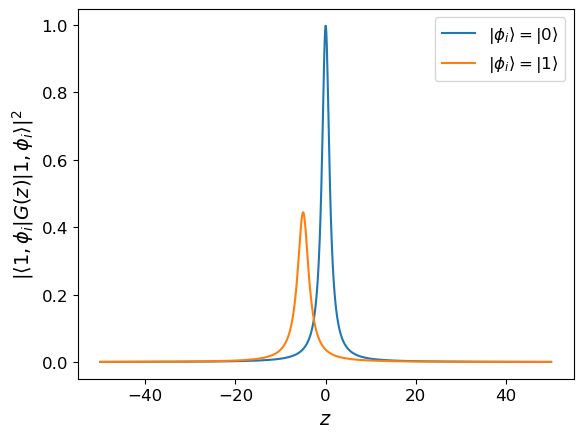

In [328]:
# Plot
#plt.plot(z, e0_tf / e0_tf.max(), label='$|\\phi_i\\rangle=|0\\rangle$')
#plt.plot(z, e2_tf / e2_tf.max(), label='$|\\phi_i\\rangle=|1\\rangle$')
plt.plot(z, e0_tf, label='$|\\phi_i\\rangle=|0\\rangle$')
plt.plot(z, e2_tf, label='$|\\phi_i\\rangle=|1\\rangle$')
plt.xlabel("$z$")
plt.ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
plt.legend()
plt.savefig("gf_testing_1atom_Δ1=5,g10=g21=0.png", format='png', dpi=300)

Text(0.5, 1.0, '$i=2$')

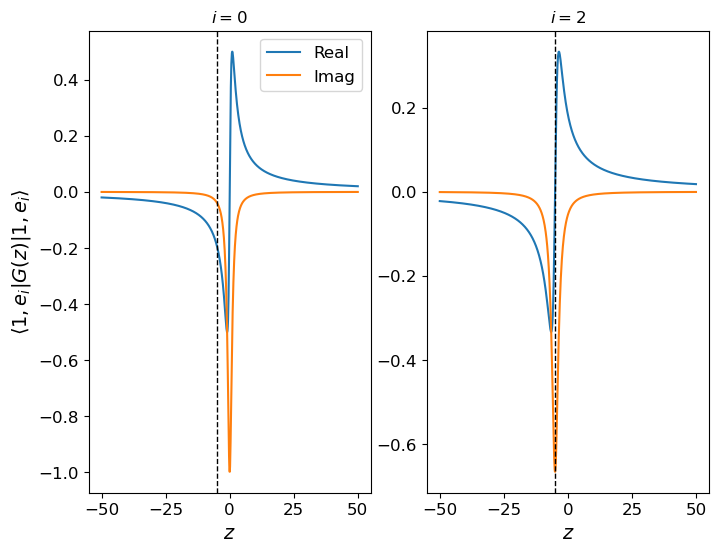

In [329]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Real')
ax[0].plot(z, e0_tamp.imag, label='Imag')
ax[0].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_i|G(z)|1,e_i\\rangle$")
ax[0].set_title("$i=0$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.real)
ax[1].plot(z, e2_tamp.imag)
ax[1].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
#ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$i=2$")

In [332]:
test = np.array([e0.dag() * _ * e2 for _ in sa_exact_Gs])

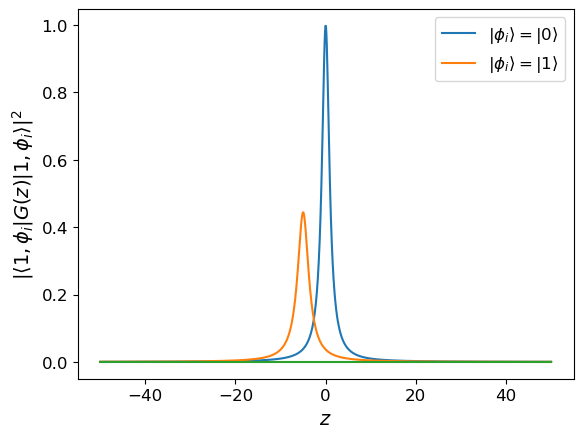

In [334]:
plt.plot(z, e0_tf, label='$|\\phi_i\\rangle=|0\\rangle$')
plt.plot(z, e2_tf, label='$|\\phi_i\\rangle=|1\\rangle$')
plt.plot(z, np.abs(test) ** 2)
plt.xlabel("$z$")
plt.ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
plt.legend()

#### c) $g_{10} \neq 0$

In [311]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [0]
g10s = [5]
g21s = [0]

In [312]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j  5.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [5.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.-0.5j 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.-1.j  5.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  5.+0.j  0.-2.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.5j]]

In [313]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [314]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [315]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([-4.97493719-0.5j,  0.        -0.5j,  4.97493719-0.5j]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.70710678+0.j        ]
        [-0.70356236-0.07071068j]
        [ 0.        +0.j        ]]                                           ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.70356236+0.07071068j]
        [ 0.70710678+0.j        ]
        [-0.        +0.j        ]]                                           ],
      dtype=object))


In [316]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([-4.97493719-1.5j, -4.97493719-0.5j,  0.        -1.5j,
         0.        -0.5j,  4.97493719-0.5j,  4.97493719-1.5j]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.70356236+0.07071068j]
         [ 0.70710678+0.j        ]
         [-0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.70710678+0.j        ]
         [-0.70356236-0.07071068j]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [

In [319]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][0].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][5].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

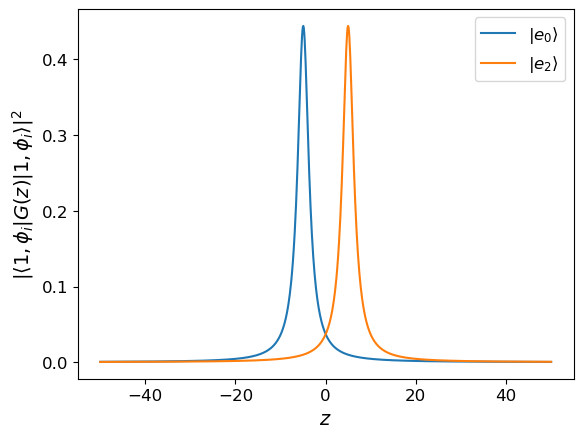

In [320]:
# Plot
#plt.plot(z, e0_tf / e0_tf.max(), label='$|e_0\\rangle$')
#plt.plot(z, e2_tf / e2_tf.max(), label='$|e_2\\rangle$')
plt.plot(z, e0_tf, label='$|e_0\\rangle$')
plt.plot(z, e2_tf, label='$|e_2\\rangle$')
plt.xlabel("$z$")
plt.ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
plt.legend()
#plt.savefig("gf_testing_1atom_Δ1=0,g10=5,g21=0.png", format='png', dpi=300)

Text(0.5, 1.0, '$i=2$')

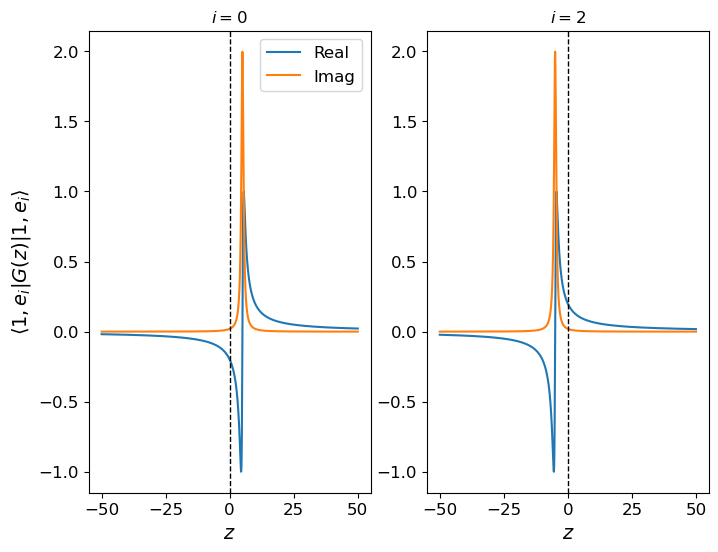

In [225]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Real')
ax[0].plot(z, e0_tamp.imag, label='Imag')
ax[0].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_i|G(z)|1,e_i\\rangle$")
ax[0].set_title("$i=0$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.real)
ax[1].plot(z, e2_tamp.imag)
ax[1].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
#ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$i=2$")

#### d) $\Delta_1 \neq 0, g_{10} \neq 0$

In [226]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [5]
g10s = [5]
g21s = [0]

In [227]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   5.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 5.+0.j  -5.-1.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j  -5.-0.5j  0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+1.j   5.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   5.+0.j  -5.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j  -5.+0.5j]]

In [228]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [229]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [230]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([-8.07228154-0.72432463j, -5.        -0.5j       ,
        3.07228154-0.27567537j]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[-0.52294695+0.04692395j]
        [ 0.85107264+0.j        ]
        [ 0.        +0.j        ]]                                           ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.85107264+0.j        ]
        [ 0.52294695-0.04692395j]
        [-0.        +0.j        ]]                                           ],
      dtype=object))


In [231]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([-8.07228154-0.72432463j, -8.07228154+0.27567537j,
        -5.        -0.5j       , -5.        +0.5j       ,
         3.07228154-0.27567537j,  3.07228154+0.72432463j]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.52294695+0.04692395j]
         [ 0.85107264+0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.52294695+0.04692395j]
         [ 0.85107264+0.j        ]
         [-0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
  

In [232]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][5].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][1].copy()#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

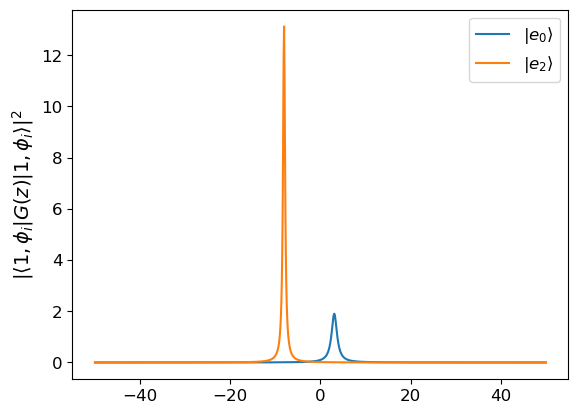

In [233]:
# Plot
#plt.plot(z, e0_tf / e0_tf.max(), label='$|e_0\\rangle$')
#plt.plot(z, e2_tf / e2_tf.max(), label='$|e_2\\rangle$')
plt.plot(z, e0_tf, label='$|e_0\\rangle$')
plt.plot(z, e2_tf, label='$|e_2\\rangle$')
plt.ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
plt.legend()
#plt.savefig("gf_testing_1atom_Δ1=5,g10=5,g21=0.png", format='png', dpi=300)

Text(0.5, 1.0, '$i=2$')

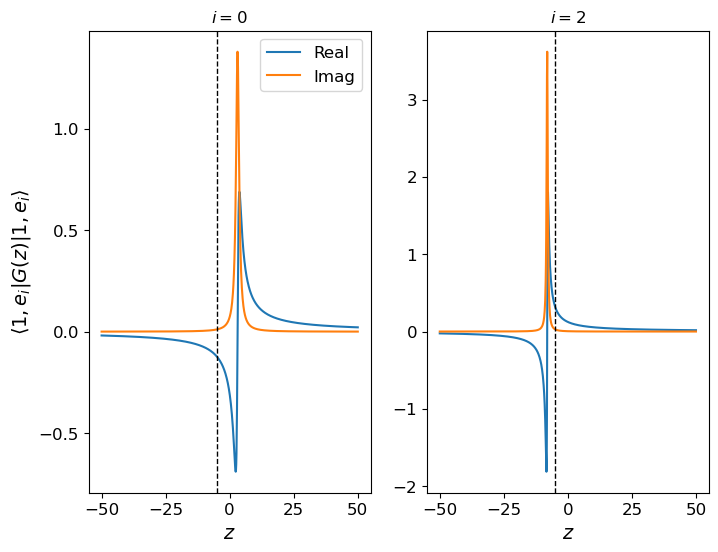

In [234]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Real')
ax[0].plot(z, e0_tamp.imag, label='Imag')
ax[0].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_i|G(z)|1,e_i\\rangle$")
ax[0].set_title("$i=0$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.real)
ax[1].plot(z, e2_tamp.imag)
ax[1].axvline(x=-Δ1s[0], color='k', linestyle='--', linewidth=1)
#ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
#ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$i=2$")

#### e) $g_{21} \neq 0$

In [235]:
# Define parameters
ωc = 1
ω21 = 0
Δ1s = [0]
g10s = [0]
g21s = [5]

In [236]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.-0.5j 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  1.+1.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.5j]]

In [237]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [238]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [239]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([0.-1.j , 0.-0.5j, 0.+0.j ]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [1.]
        [0.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[1.]
        [0.]
        [0.]]                                                                ],
      dtype=object))


In [240]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([0.-1.j , 0.-0.5j, 0.+0.j , 1.+0.j , 1.+0.5j, 1.+1.j ]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]
         [0.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [1.]

In [241]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][5]#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][3]#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

In [242]:
# Calculate the two term level shift functions
Rx_2term_e0 = get_Rx_two_term(z, e0, sa_V, sa_H0_eigs)
Rx_2term_e2 = get_Rx_two_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the four term level shift functions
Rx_4term_e0 = get_Rx_four_term(z, e0, sa_V, sa_H0_eigs)
Rx_4term_e2 = get_Rx_four_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the 6 term level shift functions
Rx_6term_e0 = get_Rx_six_term(z, e0, sa_V, sa_H0_eigs)
Rx_6term_e2 = get_Rx_six_term(z, e2, sa_V, sa_H0_eigs)

In [244]:
# Calculate the approximate Gs using the level shift functions
approx_G_2term_e0_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][5] - Rx_2term_e0[i]) for i in range(z.shape[0])])
approx_G_2term_e0 = np.abs(approx_G_2term_e0_tamp) ** 2
approx_G_2term_e2_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][3] - Rx_2term_e2[i]) for i in range(z.shape[0])])
approx_G_2term_e2 = np.abs(approx_G_2term_e2_tamp) ** 2

approx_G_4term_e0_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][5] - Rx_4term_e0[i]) for i in range(z.shape[0])])
approx_G_4term_e0 = np.abs(approx_G_4term_e0_tamp) ** 2
approx_G_4term_e2_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][3] - Rx_4term_e2[i]) for i in range(z.shape[0])])
approx_G_4term_e2 = np.abs(approx_G_4term_e2_tamp) ** 2

approx_G_6term_e0_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][5] - Rx_6term_e0[i]) for i in range(z.shape[0])])
approx_G_6term_e0 = np.abs(approx_G_6term_e0_tamp) ** 2
approx_G_6term_e2_tamp = np.array([1 / (z[i] - sa_H0_eigs[0][3] - Rx_6term_e2[i]) for i in range(z.shape[0])])
approx_G_6term_e2 = np.abs(approx_G_6term_e2_tamp) ** 2

Text(0.5, 1.0, '$|\\phi_i\\rangle = |\\epsilon_2\\rangle$')

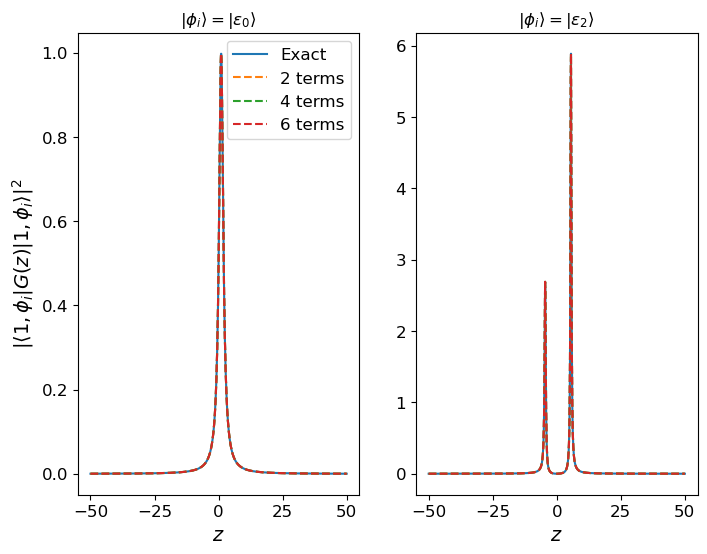

In [245]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
#ax[0].plot(z, e0_tf / e0_tf.max(), label='Exact')
#ax[0].plot(z, approx_G_2term_e0 / approx_G_2term_e0.max(), '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0 / approx_G_4term_e0.max(), '--', label='4 terms')
#ax[0].plot(z, approx_G_6term_e0 / approx_G_6term_e0.max(), '--', label='6 terms')
ax[0].plot(z, e0_tf, label='Exact')
ax[0].plot(z, approx_G_2term_e0, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
ax[0].set_title("$|\\phi_i\\rangle = |\\epsilon_0\\rangle$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e2 / approx_G_4term_e2.max(), '--')
#ax[1].plot(z, approx_G_6term_e2 / approx_G_6term_e2.max(), '--')
ax[1].plot(z, e2_tf)
ax[1].plot(z, approx_G_2term_e2, '--')
ax[1].plot(z, approx_G_4term_e2, '--')
ax[1].plot(z, approx_G_6term_e2, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$|\\phi_i\\rangle = |\\epsilon_2\\rangle$")
#fig.savefig("gf_testing_1atom_Δ1=0,g10=0,g21=5.png", format='png', dpi=300)

Text(0.5, 1.0, 'Imag')

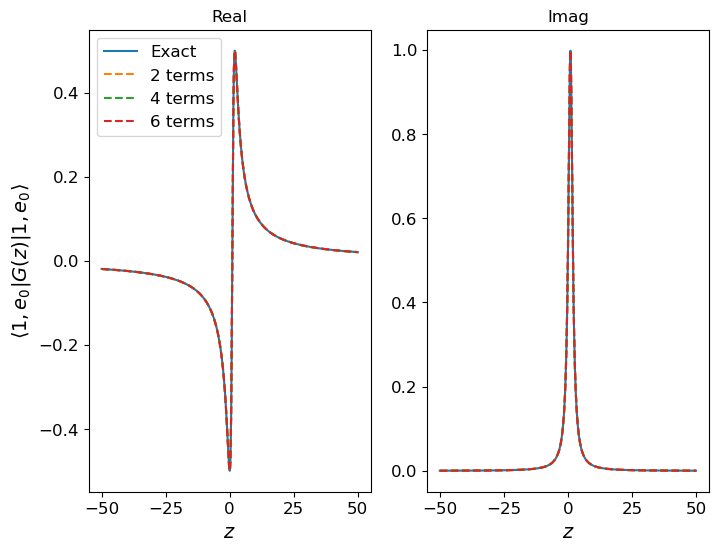

In [246]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_0|G(z)|1,e_0\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e0_tamp.imag)
ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

Text(0.5, 1.0, 'Imag')

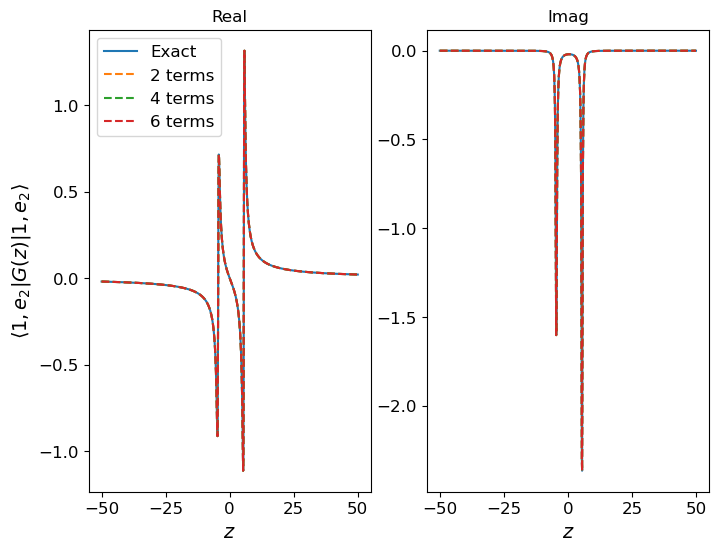

In [247]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e2_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e2_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e2_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e2_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_2|G(z)|1,e_2\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.imag)
ax[1].plot(z, approx_G_2term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e2_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

#### f) $\Delta_1 \neq 0, g_{21} \neq 0$

In [248]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [5]
g10s = [0]
g21s = [5]

In [249]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j  -5.-1.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j  -5.-0.5j  0.+0.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+1.j   0.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+0.j  -5.+0.j   0.+0.j ]
 [ 0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j  -5.+0.5j]]

In [250]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [251]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [252]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([-5.-1.j , -5.-0.5j,  0.+0.j ]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [1.]
        [0.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[1.]
        [0.]
        [0.]]                                                                ],
      dtype=object))


In [253]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([-5.-1.j , -5.-0.5j, -5.+0.j , -5.+0.5j,  0.+0.j ,  0.+1.j ]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
       

In [254]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][5]#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][2]#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

In [255]:
# Calculate the two term level shift functions
Rx_2term_e0 = get_Rx_two_term(z, e0, sa_V, sa_H0_eigs)
Rx_2term_e2 = get_Rx_two_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the four term level shift functions
Rx_4term_e0 = get_Rx_four_term(z, e0, sa_V, sa_H0_eigs)
Rx_4term_e2 = get_Rx_four_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the 6 term level shift functions
Rx_6term_e0 = get_Rx_six_term(z, e0, sa_V, sa_H0_eigs)
Rx_6term_e2 = get_Rx_six_term(z, e2, sa_V, sa_H0_eigs)

In [256]:
# Calculate the approximate Gs using the level shift functions
approx_G_2term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_2term_e0[i]) for i in range(z.shape[0])])
approx_G_2term_e0 = np.abs(approx_G_2term_e0_tamp) ** 2
approx_G_2term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][2] - Rx_2term_e2[i]) for i in range(z.shape[0])])
approx_G_2term_e2 = np.abs(approx_G_2term_e2_tamp) ** 2

approx_G_4term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_4term_e0[i]) for i in range(z.shape[0])])
approx_G_4term_e0 = np.abs(approx_G_4term_e0_tamp) ** 2
approx_G_4term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][2] - Rx_4term_e2[i]) for i in range(z.shape[0])])
approx_G_4term_e2 = np.abs(approx_G_4term_e2_tamp) ** 2

approx_G_6term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_6term_e0[i]) for i in range(z.shape[0])])
approx_G_6term_e0 = np.abs(approx_G_6term_e0_tamp) ** 2
approx_G_6term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][2] - Rx_6term_e2[i]) for i in range(z.shape[0])])
approx_G_6term_e2 = np.abs(approx_G_6term_e2_tamp) ** 2

Text(0.5, 1.0, '$|\\phi_i\\rangle = |\\epsilon_2\\rangle$')

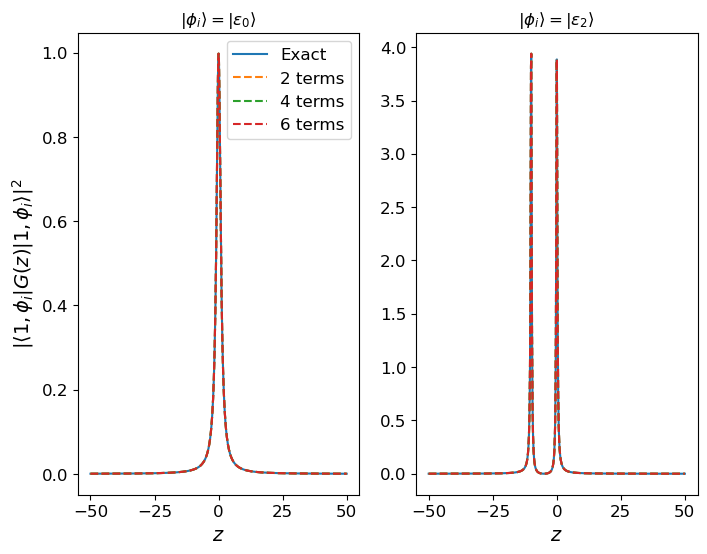

In [257]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
#ax[0].plot(z, e0_tf / e0_tf.max(), label='Exact')
#ax[0].plot(z, approx_G_2term_e0 / approx_G_2term_e0.max(), '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0 / approx_G_4term_e0.max(), '--', label='4 terms')
#ax[0].plot(z, approx_G_6term_e0 / approx_G_6term_e0.max(), '--', label='6 terms')
ax[0].plot(z, e0_tf, label='Exact')
ax[0].plot(z, approx_G_2term_e0, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
ax[0].set_title("$|\\phi_i\\rangle = |\\epsilon_0\\rangle$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e2 / approx_G_4term_e2.max(), '--')
#ax[1].plot(z, approx_G_6term_e2 / approx_G_6term_e2.max(), '--')
ax[1].plot(z, e2_tf)
ax[1].plot(z, approx_G_2term_e2, '--')
ax[1].plot(z, approx_G_4term_e2, '--')
ax[1].plot(z, approx_G_6term_e2, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$|\\phi_i\\rangle = |\\epsilon_2\\rangle$")
#fig.savefig("gf_testing_1atom_Δ1=5,g10=0,g21=5.png", format='png', dpi=300)

Text(0.5, 1.0, 'Imag')

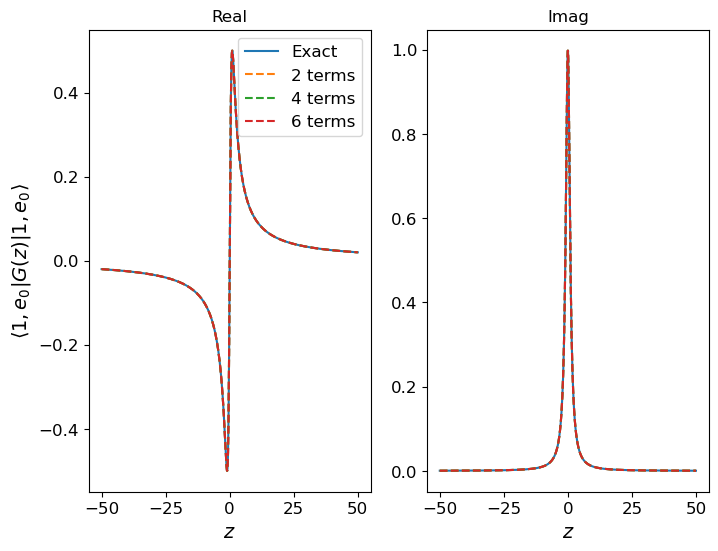

In [258]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_0|G(z)|1,e_0\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e0_tamp.imag)
ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

Text(0.5, 1.0, 'Imag')

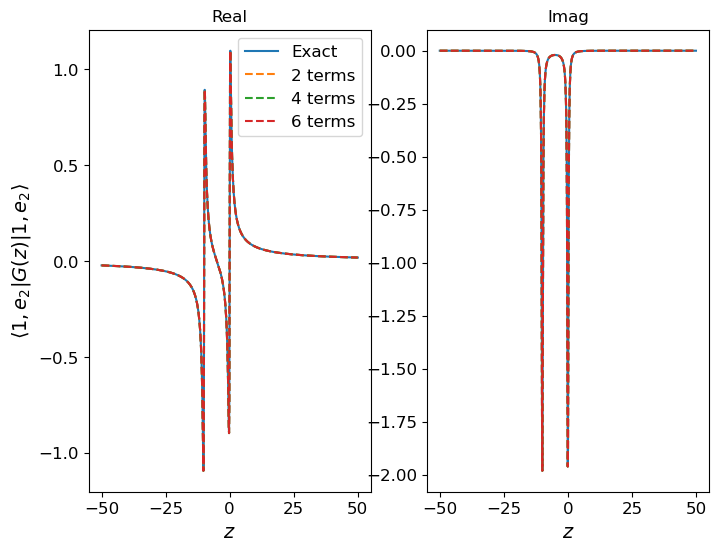

In [259]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e2_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e2_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e2_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e2_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_2|G(z)|1,e_2\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.imag)
ax[1].plot(z, approx_G_2term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e2_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

#### g) $g_{10} \neq 0, g_{21} \neq 0$

In [260]:
# Define parameters
ωc = 0
ω21 = 0
Δ1s = [0]
g10s = [5]
g21s = [5]

In [261]:
# Get H0
sa_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, 1)
sa_H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j  5.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [5.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.-0.5j 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+1.j  5.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  5.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.5j]]

In [262]:
# Get Vs
sa_V = get_V(g21s, a, σ21, Ia, 1)

In [263]:
# Calculate exact resolvents
sa_exact_Gs = [exact_resolvent(z[i], sa_H0+sa_V) for i in range(z.shape[0])]

In [264]:
# Get the single atom Hamiltonian
H_atom = get_H_atom(ω21, Δ1s[0], γ10s[0], γ21s[0], g10s[0], σ10, σ21)

# Get eigenstates
Ha_eigs = H_atom.eigenstates()
print(Ha_eigs)

(array([-4.97493719-0.5j,  0.        -0.5j,  4.97493719-0.5j]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.70710678+0.j        ]
        [-0.70356236-0.07071068j]
        [ 0.        +0.j        ]]                                           ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [1.]]                                                                ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.70356236+0.07071068j]
        [ 0.70710678+0.j        ]
        [-0.        +0.j        ]]                                           ],
      dtype=object))


In [265]:
# Get the eigenstates of H0
sa_H0_eigs = sa_H0.eigenstates()
sa_H0_eigs

(array([-4.97493719-0.5j, -4.97493719+0.5j,  0.        -0.5j,
         0.        +0.5j,  4.97493719-0.5j,  4.97493719+0.5j]),
 array([Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.70710678+0.j        ]
         [-0.70356236-0.07071068j]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.        +0.j        ]
         [-0.70356236+0.07071068j]
         [ 0.70710678+0.j        ]
         [-0.        +0.j        ]]                                              ,
        Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [

In [266]:
# Define the e0 and e1 that we want to calculate transmission from
e0 = sa_H0_eigs[1][5]#qu.tensor(qu.basis(2,1), Ha_eigs[1][0])
e2 = sa_H0_eigs[1][1]#qu.tensor(qu.basis(2,1), Ha_eigs[1][2])

# Calculate the transmission amplitudes
e0_tamp = np.array([e0.dag() * _ * e0 for _ in sa_exact_Gs])
e0_tf = np.abs(e0_tamp) ** 2
e2_tamp = np.array([e2.dag() * _ * e2 for _ in sa_exact_Gs])
e2_tf = np.abs(e2_tamp) ** 2

In [267]:
# Calculate the two term level shift functions
Rx_2term_e0 = get_Rx_two_term(z, e0, sa_V, sa_H0_eigs)
Rx_2term_e2 = get_Rx_two_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the four term level shift functions
Rx_4term_e0 = get_Rx_four_term(z, e0, sa_V, sa_H0_eigs)
Rx_4term_e2 = get_Rx_four_term(z, e2, sa_V, sa_H0_eigs)

# Calculate the 6 term level shift functions
Rx_6term_e0 = get_Rx_six_term(z, e0, sa_V, sa_H0_eigs)
Rx_6term_e2 = get_Rx_six_term(z, e2, sa_V, sa_H0_eigs)

In [268]:
# Calculate the approximate Gs using the level shift functions
approx_G_2term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_2term_e0[i]) for i in range(z.shape[0])])
approx_G_2term_e0 = np.abs(approx_G_2term_e0_tamp) ** 2
approx_G_2term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][1] - Rx_2term_e2[i]) for i in range(z.shape[0])])
approx_G_2term_e2 = np.abs(approx_G_2term_e2_tamp) ** 2

approx_G_4term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_4term_e0[i]) for i in range(z.shape[0])])
approx_G_4term_e0 = np.abs(approx_G_4term_e0_tamp) ** 2
approx_G_4term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][1] - Rx_4term_e2[i]) for i in range(z.shape[0])])
approx_G_4term_e2 = np.abs(approx_G_4term_e2_tamp) ** 2

approx_G_6term_e0_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][5] - Rx_6term_e0[i]) for i in range(z.shape[0])])
approx_G_6term_e0 = np.abs(approx_G_6term_e0_tamp) ** 2
approx_G_6term_e2_tamp = np.array([1 / (z[i]+ωc - sa_H0_eigs[0][1] - Rx_6term_e2[i]) for i in range(z.shape[0])])
approx_G_6term_e2 = np.abs(approx_G_6term_e2_tamp) ** 2

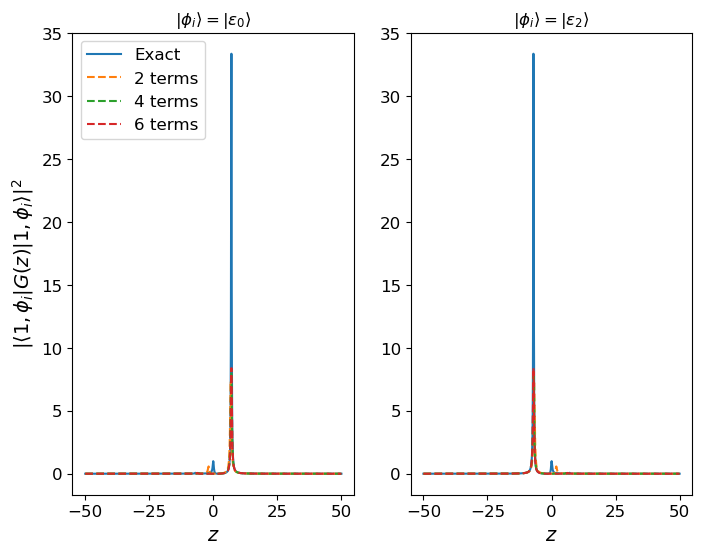

In [269]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
#ax[0].plot(z, e0_tf / e0_tf.max(), label='Exact')
#ax[0].plot(z, approx_G_2term_e0 / approx_G_2term_e0.max(), '--', label='2 terms')
#ax[0].plot(z, approx_G_4term_e0 / approx_G_4term_e0.max(), '--', label='4 terms')
#ax[0].plot(z, approx_G_6term_e0 / approx_G_6term_e0.max(), '--', label='6 terms')
ax[0].plot(z, e0_tf, label='Exact')
ax[0].plot(z, approx_G_2term_e0, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
ax[0].set_title("$|\\phi_i\\rangle = |\\epsilon_0\\rangle$")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e2 / approx_G_4term_e2.max(), '--')
#ax[1].plot(z, approx_G_6term_e2 / approx_G_6term_e2.max(), '--')
ax[1].plot(z, e2_tf)
ax[1].plot(z, approx_G_2term_e2, '--')
ax[1].plot(z, approx_G_4term_e2, '--')
ax[1].plot(z, approx_G_6term_e2, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("$|\\phi_i\\rangle = |\\epsilon_2\\rangle$")
title = "gf_testing_1atom_Δ1=" + str(Δ1s[0]) + ",g10=" + str(g10s[0]) + ",g21=" + str(g21s[0]) + ".png"
#fig.savefig(title, format='png', dpi=300)

In [270]:
# Calculate the relative error between the approximate Gs and the exact ones
err_2term_e0 = np.abs(e0_tf - approx_G_2term_e0) / np.abs(e0_tf)
err_4term_e0 = np.abs(e0_tf - approx_G_4term_e0) / np.abs(e0_tf)
err_6term_e0 = np.abs(e0_tf - approx_G_6term_e0) / np.abs(e0_tf)

err_2term_e2 = np.abs(e2_tf - approx_G_2term_e2) / np.abs(e2_tf)
err_4term_e2 = np.abs(e2_tf - approx_G_4term_e2) / np.abs(e2_tf)
err_6term_e2 = np.abs(e2_tf - approx_G_6term_e2) / np.abs(e2_tf)

Text(0.5, 1.0, '$|\\phi_i\\rangle = |\\epsilon_2\\rangle$')

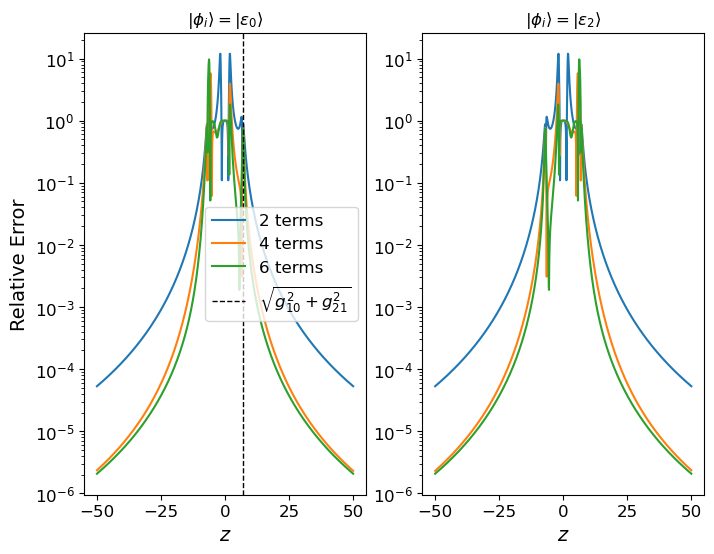

In [271]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].semilogy(z, err_2term_e0, label='2 terms')
ax[0].semilogy(z, err_4term_e0, label='4 terms')
ax[0].semilogy(z, err_6term_e0, label='6 terms')
ax[0].axvline(x=np.sqrt(g10s[0]**2+g21s[0]**2), color='k', linestyle='--', linewidth=1, label='$\\sqrt{g_{10}^2+g_{21}^2}$')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("Relative Error")
ax[0].set_title("$|\\phi_i\\rangle = |\\epsilon_0\\rangle$")
ax[0].legend()

ax[1].semilogy(z, err_2term_e2)
ax[1].semilogy(z, err_4term_e2)
ax[1].semilogy(z, err_6term_e2)
ax[1].set_xlabel("$z$")
ax[1].set_title("$|\\phi_i\\rangle = |\\epsilon_2\\rangle$")

Text(0.5, 1.0, 'Imag')

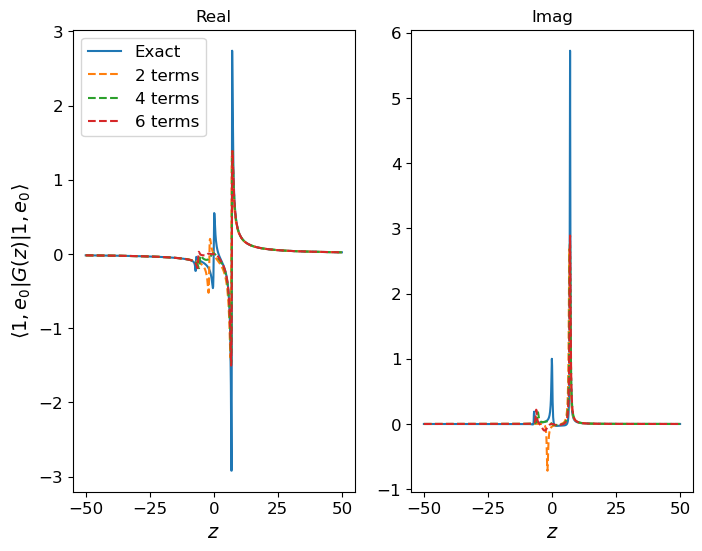

In [272]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e0_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e0_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e0_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e0_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_0|G(z)|1,e_0\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e0_tamp.imag)
ax[1].plot(z, approx_G_2term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e0_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e0_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

Text(0.5, 1.0, 'Imag')

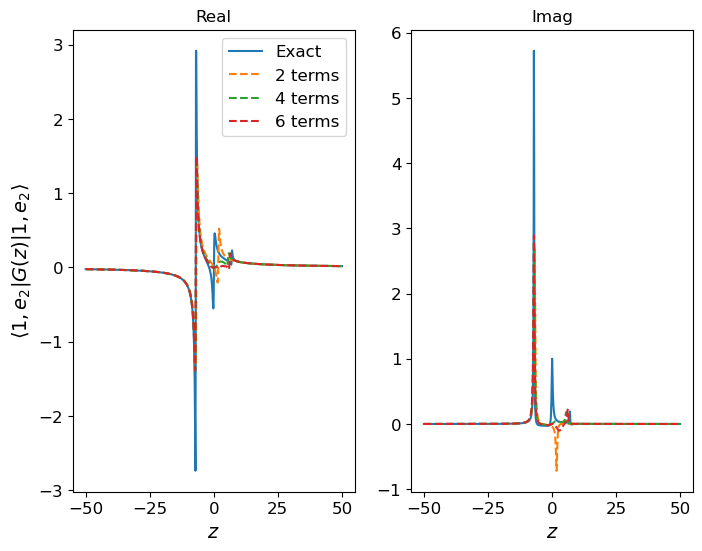

In [273]:
# Plot
fig = plt.figure(1,figsize=(8,6))
ax = fig.subplots(1,2)
ax[0].plot(z, e2_tamp.real, label='Exact')
ax[0].plot(z, approx_G_2term_e2_tamp.real, '--', label='2 terms')
ax[0].plot(z, approx_G_4term_e2_tamp.real, '--', label='4 terms')
ax[0].plot(z, approx_G_6term_e2_tamp.real, '--', label='6 terms')
#ax[0].axvline(x=0, color='k')
ax[0].set_xlabel("$z$")
ax[0].set_ylabel("$\\langle1,e_2|G(z)|1,e_2\\rangle$")
ax[0].set_title("Real")
ax[0].legend()

#ax[1].plot(z, e2_tf / e2_tf.max())
#ax[1].plot(z, approx_G_2term_e2 / approx_G_2term_e2.max(), '--')
#ax[1].plot(z, approx_G_4term_e0 / approx_G_4term_e2.max(), '--')
ax[1].plot(z, e2_tamp.imag)
ax[1].plot(z, approx_G_2term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_4term_e2_tamp.imag, '--')
ax[1].plot(z, approx_G_6term_e2_tamp.imag, '--')
ax[1].set_xlabel("$z$")
ax[1].set_title("Imag")

I also want to double check the other eigenstates for curiousity's sake.

In [274]:
# Get the other eigenstates
e_0j0 = sa_H0_eigs[1][2]
e_0jp = sa_H0_eigs[1][0]
e_0jm = sa_H0_eigs[1][4]
e_1j0 = sa_H0_eigs[1][3]

# Calculate the transmission amplitudes
e_0j0_tf = np.abs(np.array([e_0j0.dag() * _ * e_0j0 for _ in sa_exact_Gs])) ** 2
e_0jp_tf = np.abs(np.array([e_0jp.dag() * _ * e_0jp for _ in sa_exact_Gs])) ** 2
e_0jm_tf = np.abs(np.array([e_0jm.dag() * _ * e_0jm for _ in sa_exact_Gs])) ** 2
e_1j0_tf = np.abs(np.array([e_1j0.dag() * _ * e_1j0 for _ in sa_exact_Gs])) ** 2

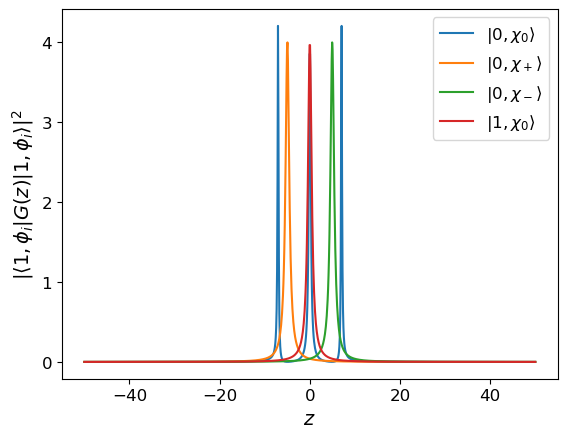

In [275]:
plt.plot(z, e_0j0_tf, label='$|0,\\chi_0\\rangle$')
plt.plot(z, e_0jp_tf, label='$|0,\\chi_+\\rangle$')
plt.plot(z, e_0jm_tf, label='$|0,\\chi_-\\rangle$')
plt.plot(z, e_1j0_tf, label='$|1,\\chi_0\\rangle$')
plt.xlabel("$z$")
plt.ylabel("$|\\langle1,\\phi_i|G(z)|1,\\phi_i\\rangle|^2$")
plt.legend()

### II) Two Atoms

In [86]:
# Get H0
da_H0 = get_H0(ωc, ω21, Δ1s, κ, γ10s, γ21s, g10s, a, σ10, σ21, Ic, Ia, N)

NameError: name 'N' is not defined

In [ ]:
# Get V
da_V = get_V(g21s, a, σ21, Ia, N)

In [ ]:
# Get the exact resolvent
da_exact_Gs = [exact_resolvent(z[i], da_H0+da_V) for i in range(z.shape[0])]

In [ ]:
# Get the eigenstates of the combined system
da_eigs = qu.tensor(H_atom, H_atom).eigenstates()
print(da_eigs)